# Gradient Boosting Regressor GK Volatility Prediction

**Task**: Predict next-hour GK Volatility (`target_reg`)  
**Models**: Gradient Boosting from scratch vs sklearn  
**How it works**: Builds trees **sequentially** each tree corrects the residual errors of the previous one  
**Evaluation**: MSE, RMSE, MAE, R², MAPE, loss curves, residuals, feature importance


---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor as SklearnTree

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

print('Setup complete')


Setup complete


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)
    
X_train = train[feature_cols].values
X_test  = test[feature_cols].values

from sklearn.preprocessing import StandardScaler as TargetScaler
y_scaler = TargetScaler()
y_train  = y_scaler.fit_transform(train['target_reg'].values.reshape(-1,1)).ravel()
y_test   = y_scaler.transform(test['target_reg'].values.reshape(-1,1)).ravel()

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train : {X_train.shape} | Test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'y_train  mean={y_train.mean():.4f}  std={y_train.std():.4f}')


Train : (60260, 10) | Test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']
y_train  mean=0.0000  std=1.0000


---
## 2. Data Analysis

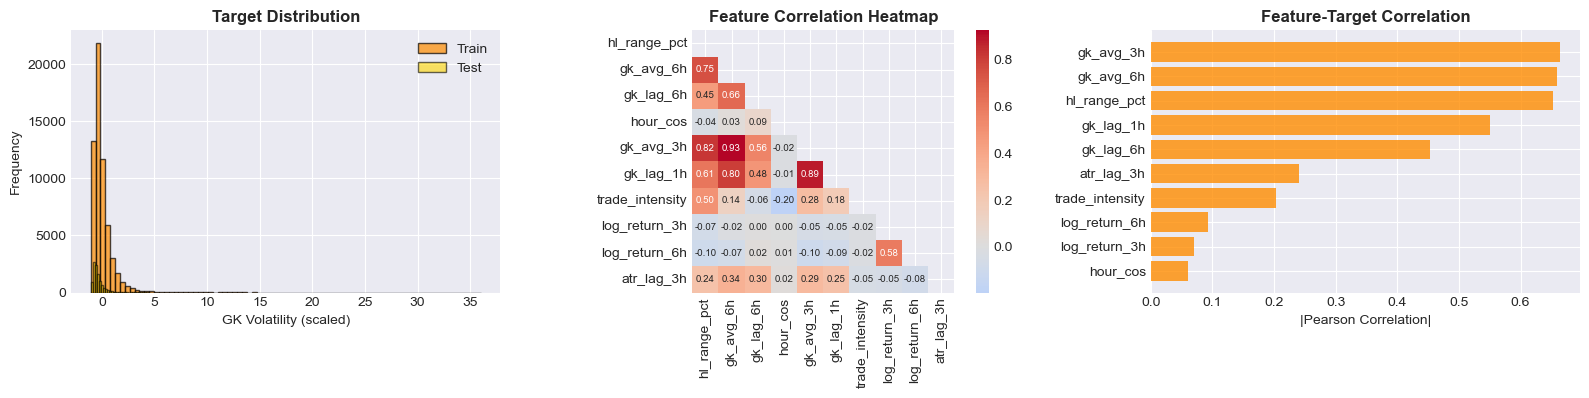

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='darkorange', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='gold',       edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility (scaled)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution', fontweight='bold'); axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr    = df_feat.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_corr.index, feat_corr.values, color='darkorange', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Gradient Boosting from Scratch

**Algorithm** (MSE loss):
1. Initialise $F_0(x) = \bar{y}$ (mean of targets)
2. For $m = 1 \ldots M$:
   - Compute **residuals** (negative gradient): $r_i = y_i - F_{m-1}(x_i)$
   - Fit a shallow decision tree $h_m$ to the residuals
   - Update: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$
3. Final prediction: $F_M(x)$

Uses **sklearn's DecisionTreeRegressor** as the base learner (depth=3) for speed.  
The boosting logic (residuals, sequential updates, learning rate) is fully from scratch.


In [4]:
class GradientBoostingRegressorScratch:
    """
    Gradient Boosting Regressor from scratch using MSE loss.

    Each iteration:
      1. Compute residuals = y - current predictions
      2. Fit a shallow tree to the residuals
      3. Update predictions: F += learning_rate * tree.predict(X)

    Base learner: sklearn DecisionTreeRegressor (depth=3) for speed.
    The boosting logic is fully hand-coded.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, subsample=0.8,
                 random_state=42, verbose=True):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.max_depth     = max_depth
        self.subsample     = subsample
        self.random_state  = random_state
        self.verbose       = verbose
        self.trees_        = []
        self.F0_           = None
        self.train_losses  = []
        self.val_losses    = []

    def fit(self, X, y, X_val=None, y_val=None):
        np.random.seed(self.random_state)
        n = len(y)

        self.F0_ = float(y.mean())
        F = np.full(n, self.F0_)
        self.trees_ = []
        self.train_losses = []
        self.val_losses   = []

        if X_val is not None:
            F_val = np.full(len(y_val), self.F0_)

        t0 = time.time()
        for m in range(self.n_estimators):
            residuals = y - F

            n_sub = max(1, int(n * self.subsample))
            idx   = np.random.choice(n, n_sub, replace=False)

            tree = SklearnTree(max_depth=self.max_depth, random_state=self.random_state)
            tree.fit(X[idx], residuals[idx])
            self.trees_.append(tree)

            F     += self.learning_rate * tree.predict(X)
            if X_val is not None:
                F_val += self.learning_rate * tree.predict(X_val)

            train_mse = float(mean_squared_error(y, F))
            self.train_losses.append(train_mse)
            if X_val is not None:
                self.val_losses.append(float(mean_squared_error(y_val, F_val)))

            if self.verbose and (m + 1) % 20 == 0:
                elapsed = time.time() - t0
                msg = f'  Iter {m+1:4d}/{self.n_estimators}  Train MSE: {train_mse:.8f}'
                if X_val is not None:
                    msg += f'  Val MSE: {self.val_losses[-1]:.8f}'
                msg += f'  ({elapsed:.0f}s)'
                print(msg)

        return self

    def predict(self, X):
        F = np.full(len(X), self.F0_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        return F

    def staged_predict(self, X):
        """Yield predictions after each boosting stage for learning curve."""
        F = np.full(len(X), self.F0_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
            yield F.copy()

print('GradientBoostingRegressorScratch defined')
print('Algorithm: F_m(x) = F_{m-1}(x) + η · h_m(x)')
print('Base learner: shallow DecisionTree (depth=3) boosting logic is scratch')


GradientBoostingRegressorScratch defined
Algorithm: F_m(x) = F_{m-1}(x) + η · h_m(x)
Base learner: shallow DecisionTree (depth=3) boosting logic is scratch


---
## 4. Hyperparameter Tuning (learning rate & n_estimators)

=== Learning Rate Grid Search ===
  lr=0.05  Val R²=0.3680
  lr=0.10  Val R²=0.3656
  lr=0.20  Val R²=0.3672

Best learning rate: 0.05


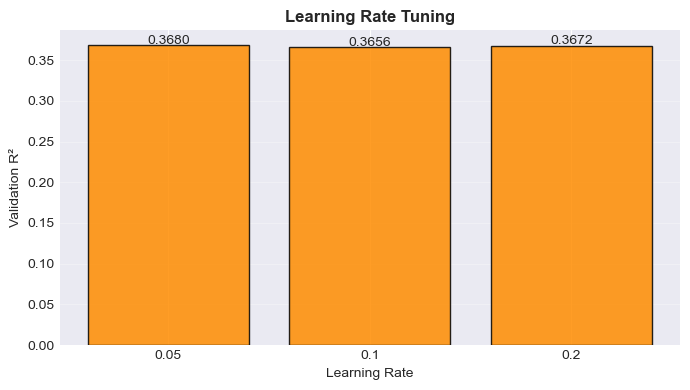

In [5]:
print("=== Learning Rate Grid Search ===")
lr_options = [0.05, 0.1, 0.2]
n_est      = 100
tune_results = []

for lr in lr_options:
    gb_tune = GradientBoostingRegressorScratch(
        n_estimators=n_est, learning_rate=lr,
        max_depth=3, subsample=0.8,
        random_state=42, verbose=False
    )
    gb_tune.fit(X_tr, y_tr)
    val_r2 = r2_score(y_val, gb_tune.predict(X_val))
    tune_results.append({'lr': lr, 'val_r2': round(val_r2, 4)})
    print(f"  lr={lr:.2f}  Val R²={val_r2:.4f}")

best_lr = max(tune_results, key=lambda x: x['val_r2'])['lr']
print(f"\nBest learning rate: {best_lr}")

# Plot tuning results
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(r['lr']) for r in tune_results],
       [r['val_r2'] for r in tune_results],
       color='darkorange', edgecolor='black', alpha=0.85)
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Validation R²')
ax.set_title('Learning Rate Tuning', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, r in enumerate(tune_results):
    ax.text(i, r['val_r2']+0.002, f"{r['val_r2']:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_lr_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Train Scratch Gradient Boosting

In [6]:
print(f"=== Training Scratch GB (lr={best_lr}, n=100) ===")
t0 = time.time()
gb_scratch = GradientBoostingRegressorScratch(
    n_estimators=100,
    learning_rate=best_lr,
    max_depth=3,
    subsample=0.8,
    random_state=42,
    verbose=True
)
gb_scratch.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
print(f"\nTraining time: {time.time()-t0:.1f}s")

y_pred_train_scratch = gb_scratch.predict(X_train)
y_pred_test_scratch  = gb_scratch.predict(X_test)
print(f"\nScratch  Train R²: {r2_score(y_train, y_pred_train_scratch):.4f}")
print(f"Scratch  Test  R²: {r2_score(y_test,  y_pred_test_scratch):.4f}")


=== Training Scratch GB (lr=0.05, n=100) ===
  Iter   20/100  Train MSE: 0.62716959  Val MSE: 0.28042492  (4s)
  Iter   40/100  Train MSE: 0.53218964  Val MSE: 0.24758211  (7s)
  Iter   60/100  Train MSE: 0.50198559  Val MSE: 0.23944197  (11s)
  Iter   80/100  Train MSE: 0.48635263  Val MSE: 0.23754118  (14s)
  Iter  100/100  Train MSE: 0.47806899  Val MSE: 0.23565539  (17s)

Training time: 17.4s

Scratch  Train R²: 0.5583
Scratch  Test  R²: 0.3718


---
## 6. sklearn Gradient Boosting

In [7]:
print(f"=== Training sklearn GB (lr={best_lr}, n=200) ===")
t0 = time.time()
gb_sk = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=best_lr,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb_sk.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.1f}s")

y_pred_train_sk = gb_sk.predict(X_train)
y_pred_test_sk  = gb_sk.predict(X_test)
print(f"sklearn  Train R²: {r2_score(y_train, y_pred_train_sk):.4f}")
print(f"sklearn  Test  R²: {r2_score(y_test,  y_pred_test_sk):.4f}")
print("\nsklearn uses 200 estimators + optimised C implementation → faster & higher R²")


=== Training sklearn GB (lr=0.05, n=200) ===
Training time: 42.2s
sklearn  Train R²: 0.5795
sklearn  Test  R²: 0.3936

sklearn uses 200 estimators + optimised C implementation → faster & higher R²


---
## 7. Regression Metrics

In [8]:
models_pred = {
    f'GB Scratch (lr={best_lr})': (y_pred_train_scratch, y_pred_test_scratch),
    f'GB sklearn (lr={best_lr})': (y_pred_train_sk,      y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)



  GB Scratch (lr=0.05)
  MSE     : 0.18372104
  RMSE    : 0.42862692
  MAE     : 0.28483004
  R²      : 0.3718
  MAPE(%) : 217.7109

  GB sklearn (lr=0.05)
  MSE     : 0.17733213
  RMSE    : 0.42110821
  MAE     : 0.26632965
  R²      : 0.3936
  MAPE(%) : 233.0770
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
  GB Scratch (lr=0.05)            Train R²: 0.558293  |  Test R²: 0.371762
  GB sklearn (lr=0.05)            Train R²: 0.579543  |  Test R²: 0.393609


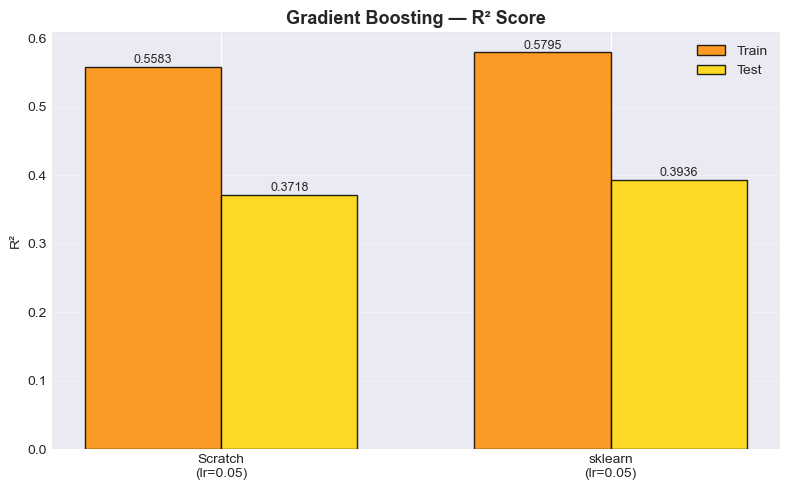

In [9]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'  {name:30s}  Train R²: {r2_score(y_train,y_tr_p):.6f}  |  Test R²: {r2_score(y_test,y_te_p):.6f}')

short = [f'Scratch\n(lr={best_lr})', f'sklearn\n(lr={best_lr})']
r2_tr = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_te = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, r2_tr, w, label='Train', color='darkorange', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_te, w, label='Test',  color='gold',       alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Gradient Boosting — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_tr),(b2,r2_te)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Loss Curves (Boosting Iterations)

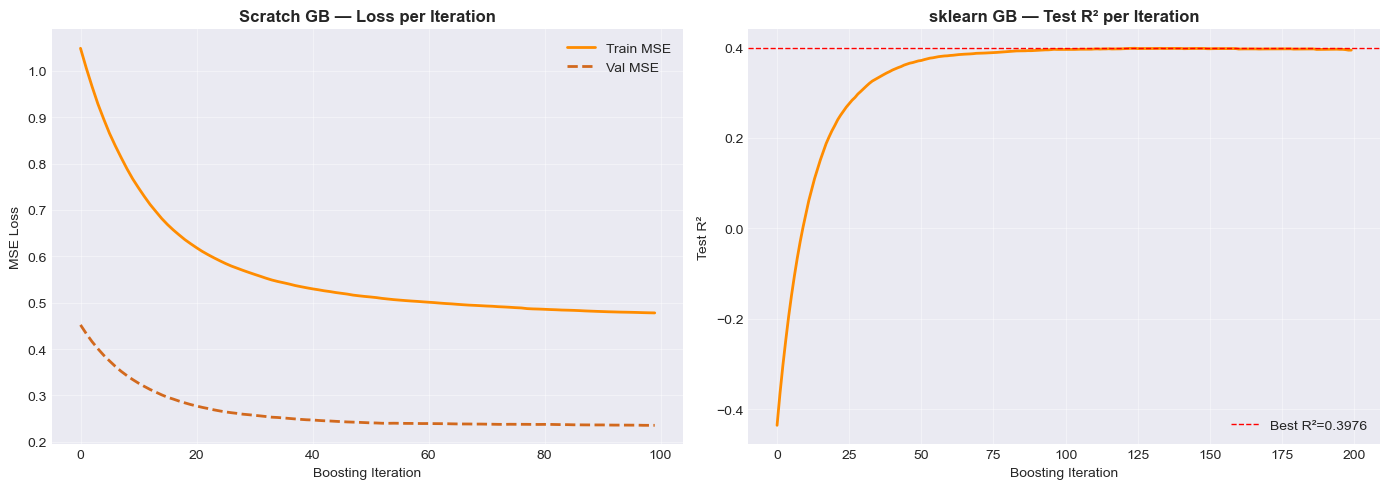

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scratch  train & val MSE per iteration
axes[0].plot(gb_scratch.train_losses, color='darkorange', lw=2,   label='Train MSE')
if gb_scratch.val_losses:
    axes[0].plot(gb_scratch.val_losses, color='chocolate', lw=2, ls='--', label='Val MSE')
axes[0].set_xlabel('Boosting Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Scratch GB — Loss per Iteration', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

# sklearn staged test R² 
staged_r2 = [r2_score(y_test, pred) for pred in gb_sk.staged_predict(X_test)]
axes[1].plot(staged_r2, color='darkorange', lw=2)
axes[1].axhline(max(staged_r2), color='red', lw=1, ls='--',
                label=f'Best R²={max(staged_r2):.4f}')
axes[1].set_xlabel('Boosting Iteration'); axes[1].set_ylabel('Test R²')
axes[1].set_title('sklearn GB — Test R² per Iteration', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Feature Importance

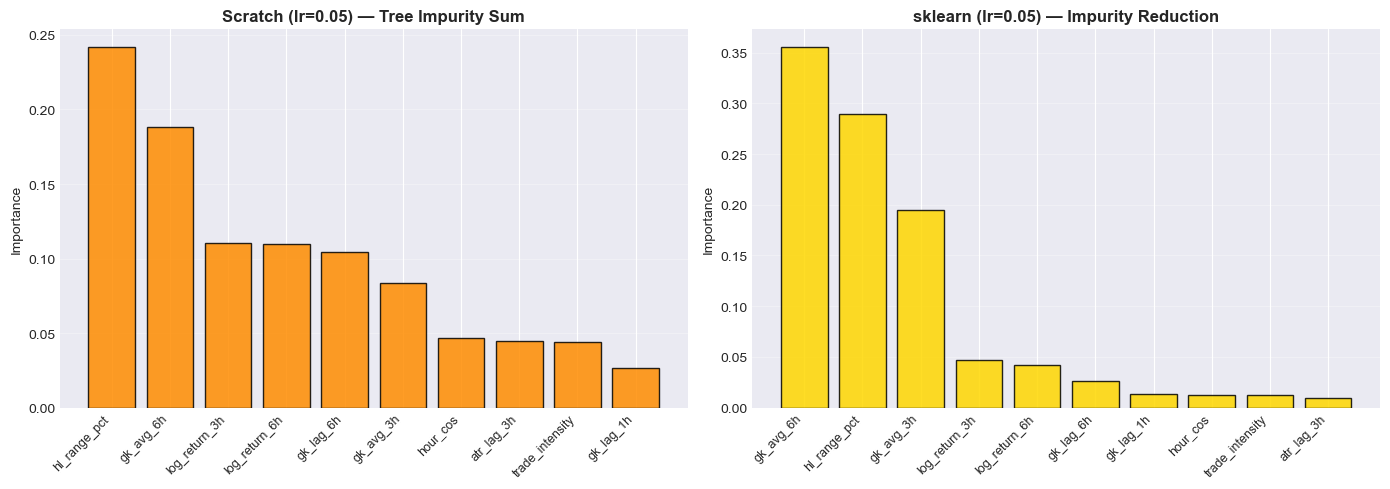

In [11]:
# sklearn feature importance (impurity reduction across all trees)
importances_sk = pd.Series(gb_sk.feature_importances_, index=feature_cols).sort_values(ascending=False)

feat_counts = np.zeros(len(feature_cols))
for tree in gb_scratch.trees_:
    fi = tree.feature_importances_
    feat_counts += fi
feat_counts /= feat_counts.sum() + 1e-10
importances_scratch = pd.Series(feat_counts, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title, color in [
    (axes[0], importances_scratch, f'Scratch (lr={best_lr}) — Tree Impurity Sum',     'darkorange'),
    (axes[1], importances_sk,      f'sklearn (lr={best_lr}) — Impurity Reduction',    'gold'),
]:
    ax.bar(imp.index, imp.values, color=color, edgecolor='black', alpha=0.85)
    ax.set_xticklabels(imp.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Actual vs Predicted & Residual Analysis

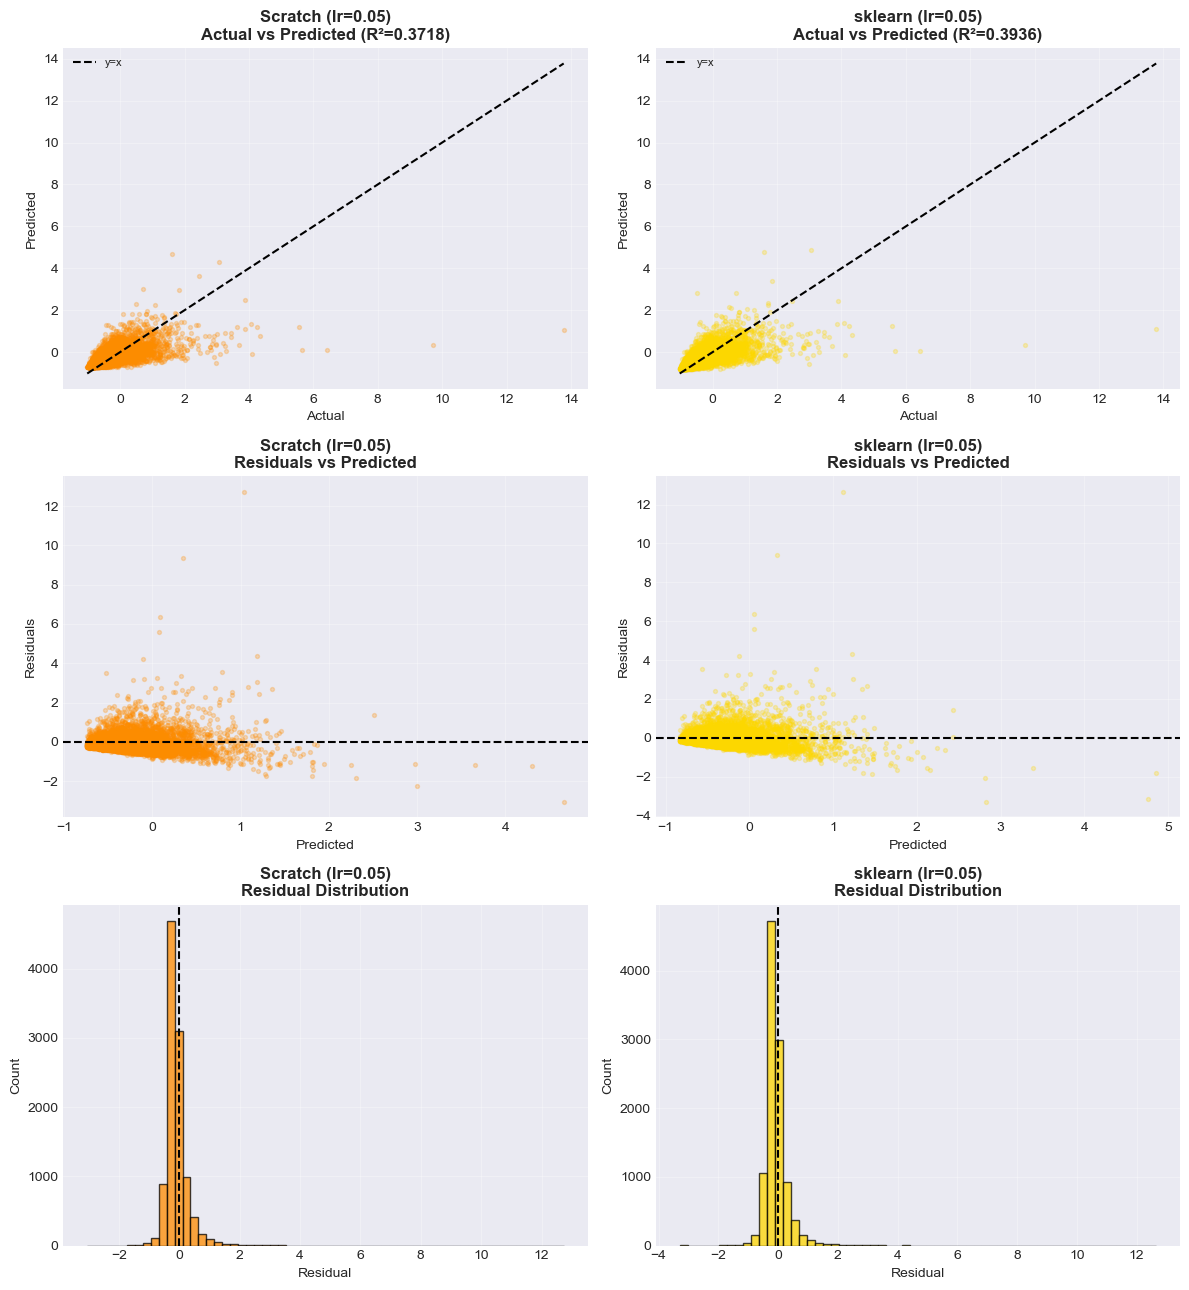

In [12]:
pred_list = [
    (f'Scratch (lr={best_lr})', y_pred_test_scratch, 'darkorange'),
    (f'sklearn (lr={best_lr})', y_pred_test_sk,      'gold'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

    axes[2,col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2,col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2,col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2,col].set_xlabel('Residual'); axes[2,col].set_ylabel('Count')
    axes[2,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Time-Series Prediction Plot

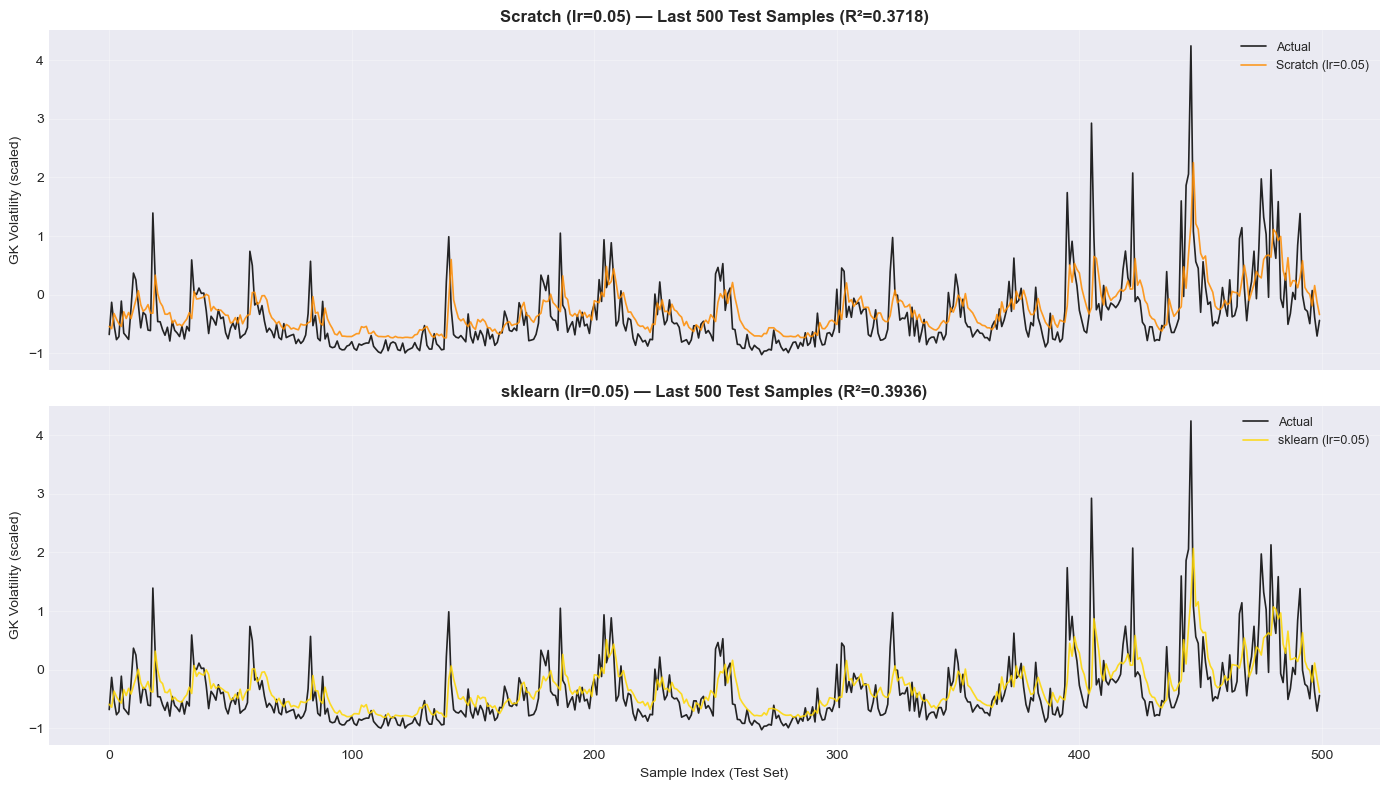

In [13]:
n_plot = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility (scaled)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 13. Save & Load Models

In [14]:
with open(os.path.join(MODELS_DIR, 'gb_scratch.pkl'),  'wb') as f: pickle.dump(gb_scratch, f)
with open(os.path.join(MODELS_DIR, 'gb_sklearn.pkl'),  'wb') as f: pickle.dump(gb_sk,      f)
with open(os.path.join(MODELS_DIR, 'gb_y_scaler.pkl'), 'wb') as f: pickle.dump(y_scaler,   f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'gb_sklearn.pkl'), 'rb') as f: m = pickle.load(f)
print(f'Load verification — sklearn GB R²: {r2_score(y_test, m.predict(X_test)):.6f}  OK')


Models saved to: d:\ML\crypto project\cryptoflow\models
Load verification — sklearn GB R²: 0.393609  OK


---
## 14. Final Summary

In [15]:
print('='*65)
print('  GRADIENT BOOSTING REGRESSOR — FINAL SUMMARY')
print('='*65)
print(f'  Scratch: n_estimators=100, lr={best_lr}, max_depth=3, subsample=0.8')
print(f'  sklearn: n_estimators=200, lr={best_lr}, max_depth=3, subsample=0.8')
print(f'  Features used: {len(feature_cols)}')
print()
print('--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:30s}  MSE={m["mse"]:.4e}  RMSE={m["rmse"]:.4e}  R²={m["r2"]:.4f}  MAPE={m["mape"]:.2f}%')
print()
print('--- Generalisation Gap ---')
for name, (y_tr_p, y_te_p) in models_pred.items():
    tr = r2_score(y_train, y_tr_p)
    te = r2_score(y_test,  y_te_p)
    print(f'  {name:30s}  Train={tr:.4f}  Test={te:.4f}  Gap={tr-te:.4f}')
print()
print('--- How Gradient Boosting Works ---')
print('  1. Start with mean prediction F0 = mean(y)')
print('  2. Each iteration: fit tree to RESIDUALS (y - current predictions)')
print('  3. Update: F_m = F_{m-1} + learning_rate * tree_m')
print('  4. Repeat until n_estimators trees built')
print('  → Each tree corrects mistakes of all previous trees')
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  GRADIENT BOOSTING REGRESSOR — FINAL SUMMARY
  Scratch: n_estimators=100, lr=0.05, max_depth=3, subsample=0.8
  sklearn: n_estimators=200, lr=0.05, max_depth=3, subsample=0.8
  Features used: 10

--- Regression Metrics (Test Set) ---
  GB Scratch (lr=0.05)            MSE=1.8372e-01  RMSE=4.2863e-01  R²=0.3718  MAPE=217.71%
  GB sklearn (lr=0.05)            MSE=1.7733e-01  RMSE=4.2111e-01  R²=0.3936  MAPE=233.08%

--- Generalisation Gap ---
  GB Scratch (lr=0.05)            Train=0.5583  Test=0.3718  Gap=0.1865
  GB sklearn (lr=0.05)            Train=0.5795  Test=0.3936  Gap=0.1859

--- How Gradient Boosting Works ---
  1. Start with mean prediction F0 = mean(y)
  2. Each iteration: fit tree to RESIDUALS (y - current predictions)
  3. Update: F_m = F_{m-1} + learning_rate * tree_m
  4. Repeat until n_estimators trees built
  → Each tree corrects mistakes of all previous trees

All plots saved to : d:\ML\crypto project\cryptoflow\plots
Results saved to   : d:\ML\crypto project\cryptoflo